# April Temporal Variability — Deep Dive

**목적**: hourly_variability_sources_041326.ipynb에서 April h3/h4 C[h,h] 이상 급등 원인 규명

| 결과 | Apr C[h,h] |
|------|------------|
| h0 | 8.22 |
| h1 | 8.99 |
| h2 | 9.33 |
| **h3** | **19.91** |
| **h4** | **86.66** |
| h5 | 8.81 |
| h6 | 8.43 |
| h7 | 9.34 |

**분석 플랜**:
1. **연도별 8×8 C 행렬** — 2022/2023/2024/2025 April 각각 따로
2. **연도별 C[h,h] diagonal** — 어느 연도가 spike를 만드나
3. **April day-by-day spatial mean per slot** — outlier day 식별
4. **Day × Hour heatmap** — 패턴이 month 전체에 consistent한지 확인
5. **Outlier day 제거 후 재계산** — spike가 특정 day 때문인지 검증

In [1]:
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path

warnings.filterwarnings('ignore')

sys.path.append("/Users/joonwonlee/Documents/GEMS_TCO-1/src")
from GEMS_TCO import configuration as config

YEARS         = ['2022', '2023', '2024', '2025']
MONTHS        = [4, 5, 6, 7, 8, 9]
LAT_RANGE     = [-3.0, 2.0]
LON_RANGE     = [121.0, 131.0]
N_SLOTS       = 8
SLOT_LABELS   = [f'h{h}' for h in range(N_SLOTS)]

year_colors  = plt.cm.Set1(np.linspace(0, 0.8, len(YEARS)))
YEAR_PALETTE = dict(zip(YEARS, year_colors))

OUT_DIR = Path("/Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/april_deep_dive/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 원본 캐시 로드 ─────────────────────────────────────────────────────────────
CACHE_PATH = Path("/Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/hourly_variability_sources/df_spatial_stats_cache.pkl")
assert CACHE_PATH.exists(), f"Cache not found: {CACHE_PATH}"
df_all = pd.read_pickle(CACHE_PATH)
print(f"Loaded: {len(df_all)} rows, columns: {list(df_all.columns)}")

# April only
df = df_all[df_all['month'] == 4].copy()
print(f"April rows: {len(df)},  years: {sorted(df['year'].unique())}")

Loaded: 5808 rows, columns: ['year', 'month', 'day_idx', 'slot', 'hours_elapsed', 'spatial_mean', 'spatial_std', 'sem_lat_lag1', 'sem_lon_lag1', 'n_obs', 'spatial_mean_c']
April rows: 960,  years: [2022, 2023, 2024, 2025]


In [2]:
def sample_cov_matrix(Y):
    """8×8 sample covariance matrix from Y (n_days × 8)."""
    n_s = Y.shape[1]
    C = np.full((n_s, n_s), np.nan)
    for h1 in range(n_s):
        for h2 in range(n_s):
            mask = np.isfinite(Y[:, h1]) & np.isfinite(Y[:, h2])
            if mask.sum() > 1:
                C[h1, h2] = np.mean(Y[mask, h1] * Y[mask, h2])
    return C


def build_Y_for_subset(sub_df):
    """
    sub_df: April data for one year (or all years)
    Returns Y (n_days × 8), day_labels list of (year, day_idx) tuples.
    spatial_mean_c must already be computed (centered within year-month).
    """
    day_order = (
        sub_df.groupby(['year', 'day_idx'])['hours_elapsed']
              .min().reset_index()
              .sort_values(['year', 'hours_elapsed'])
    )
    mat_rows, day_labels = [], []
    for _, row in day_order.iterrows():
        yr, d_idx = int(row['year']), int(row['day_idx'])
        s = sub_df[(sub_df['year'] == yr) & (sub_df['day_idx'] == d_idx)]
        vec = np.full(N_SLOTS, np.nan)
        for _, r in s.iterrows():
            vec[int(r['slot'])] = r['spatial_mean_c']
        mat_rows.append(vec)
        day_labels.append((yr, d_idx))
    return np.array(mat_rows), day_labels


def plot_cov_heatmap(ax, C, title, vmax=None, cmap='RdBu_r', annotate=True):
    _vmax = vmax if vmax else np.nanmax(np.abs(C))
    im = ax.imshow(C, cmap=cmap, vmin=-_vmax, vmax=_vmax, aspect='auto')
    ax.set_xticks(range(N_SLOTS)); ax.set_xticklabels(SLOT_LABELS, fontsize=8)
    ax.set_yticks(range(N_SLOTS)); ax.set_yticklabels(SLOT_LABELS, fontsize=8)
    ax.set_title(title, fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    if annotate:
        for h1 in range(N_SLOTS):
            for h2 in range(N_SLOTS):
                v = C[h1, h2]
                if np.isfinite(v):
                    ax.text(h2, h1, f'{v:.1f}', ha='center', va='center', fontsize=5.5,
                            color='white' if abs(v) > _vmax * 0.55 else 'black')
    return im

print("Helper functions ready.")

Helper functions ready.


---
## Section 1 — Year-by-Year 8×8 Covariance Matrix (April)

2022, 2023, 2024, 2025 각각 따로 C 행렬 계산 → h3/h4 spike가 매년 나타나는지 확인

In [3]:
yearly_C = {}
yearly_Y = {}
yearly_day_labels = {}

for yr in YEARS:
    sub = df[df['year'] == int(yr)].copy()
    if len(sub) == 0:
        print(f"{yr}: no data")
        continue
    Y_yr, labels = build_Y_for_subset(sub)
    yearly_Y[yr] = Y_yr
    yearly_day_labels[yr] = labels
    C_yr = sample_cov_matrix(Y_yr)
    yearly_C[yr] = C_yr
    n_days_yr = Y_yr.shape[0]
    diag = np.diag(C_yr)
    print(f"\n{yr}  ({n_days_yr} days)")
    print(f"  C[h,h]: " + "  ".join(f"{SLOT_LABELS[h]}={diag[h]:.2f}" for h in range(N_SLOTS)))


2022  (30 days)
  C[h,h]: h0=4.79  h1=4.98  h2=5.56  h3=5.64  h4=5.16  h5=5.16  h6=5.13  h7=5.56

2023  (30 days)
  C[h,h]: h0=7.51  h1=7.72  h2=8.38  h3=50.92  h4=318.80  h5=8.29  h6=7.59  h7=7.73

2024  (30 days)
  C[h,h]: h0=14.94  h1=17.62  h2=17.29  h3=16.99  h4=16.96  h5=16.20  h6=15.69  h7=17.04

2025  (30 days)
  C[h,h]: h0=5.62  h1=5.63  h2=6.09  h3=6.09  h4=5.72  h5=5.58  h6=5.33  h7=7.05


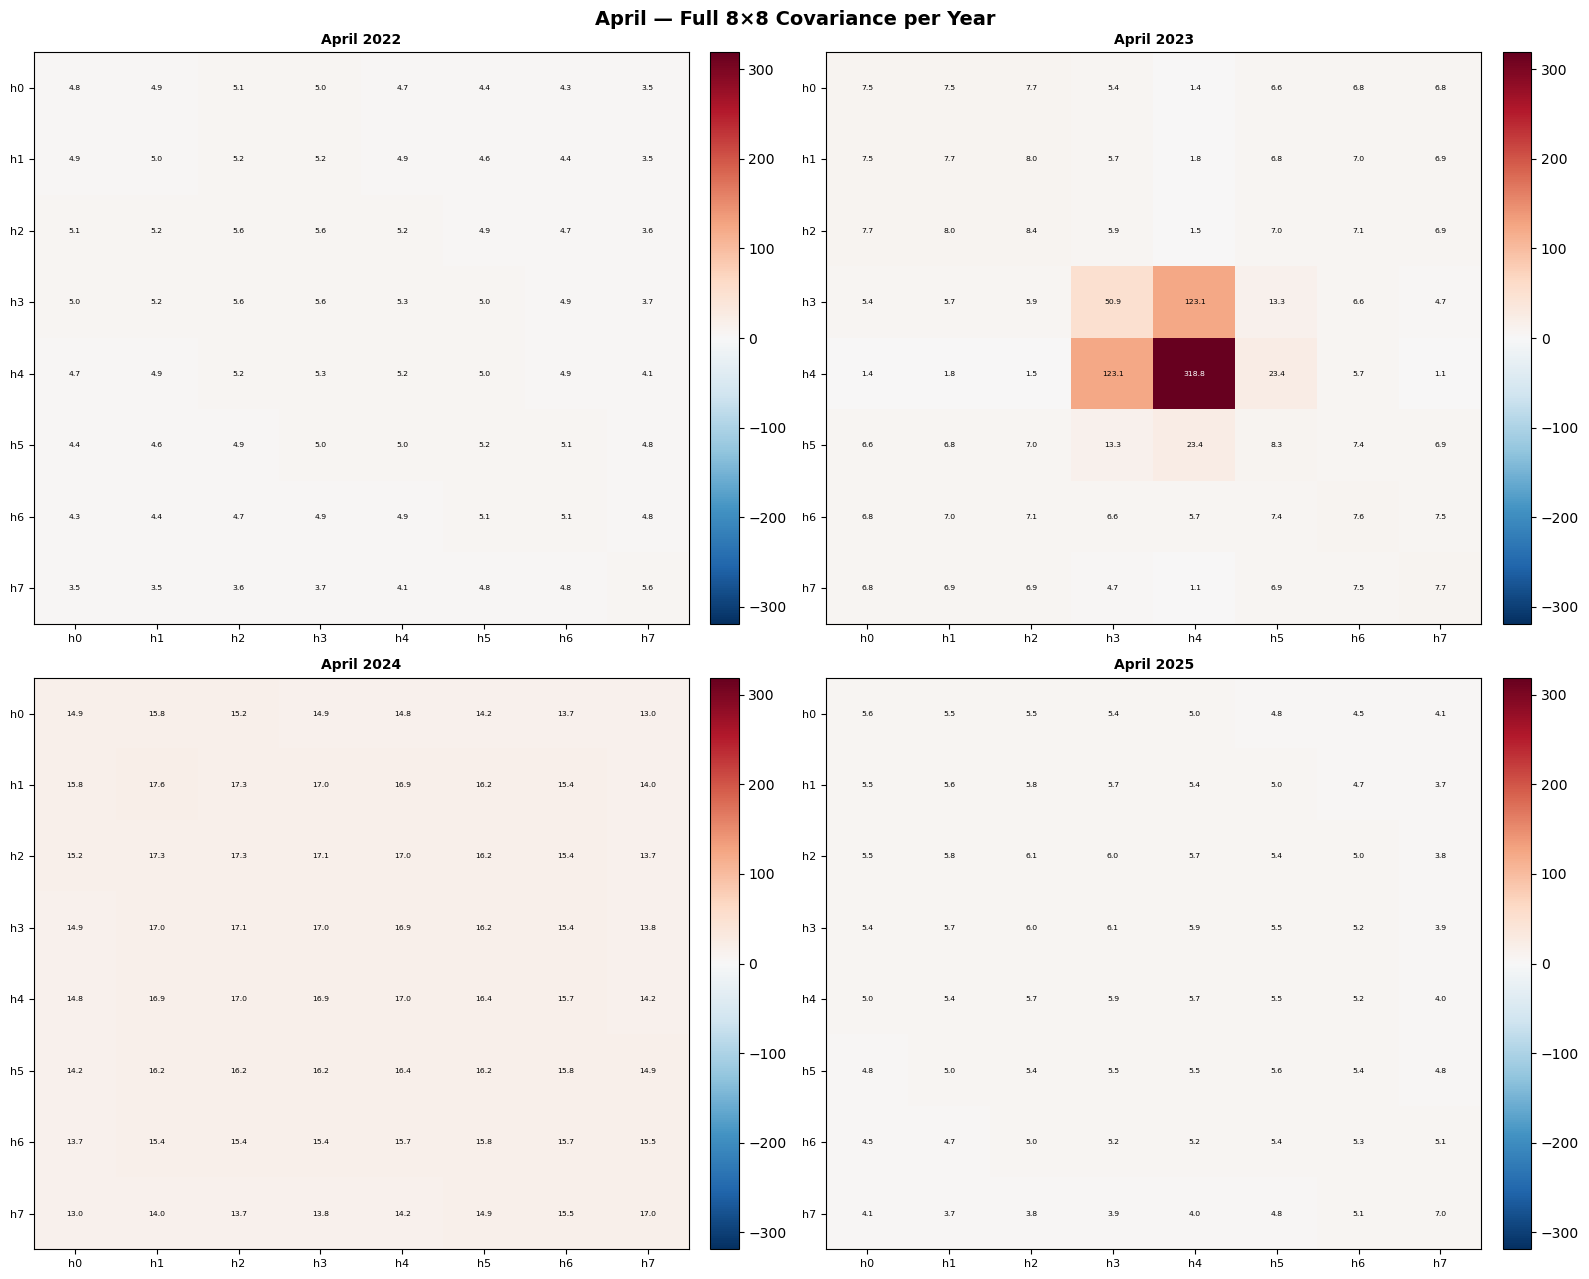

Saved → apr_yearly_cov_8x8.png


In [4]:
# ── 연도별 8×8 heatmap (2×2) ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle('April — Full 8×8 Covariance per Year', fontsize=14, fontweight='bold')

vmax_global = max(np.nanmax(np.abs(yearly_C[yr])) for yr in yearly_C)

for ax, yr in zip(axes.ravel(), YEARS):
    if yr not in yearly_C:
        ax.set_visible(False)
        continue
    plot_cov_heatmap(ax, yearly_C[yr], title=f'April {yr}', vmax=vmax_global)

plt.tight_layout()
plt.savefig(OUT_DIR / 'apr_yearly_cov_8x8.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → apr_yearly_cov_8x8.png")

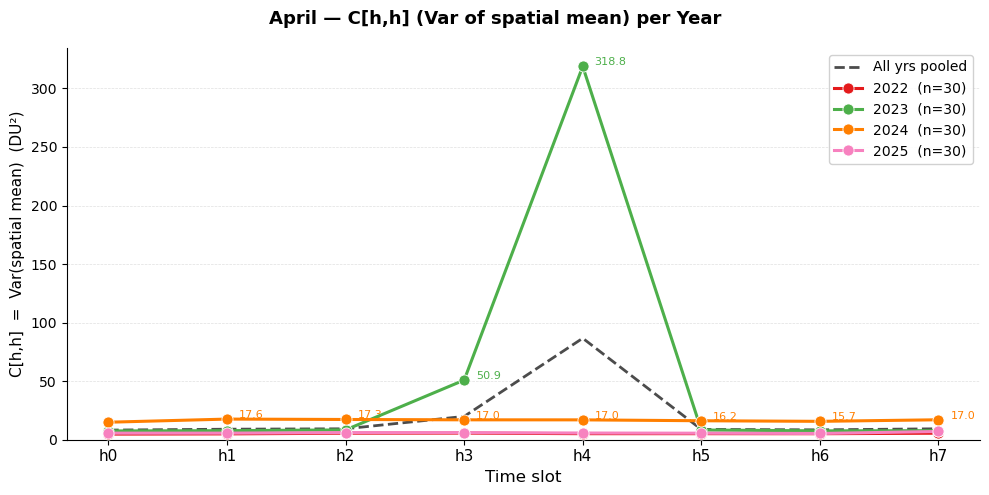

Saved → apr_yearly_diag.png


In [5]:
# ── 연도별 C[h,h] diagonal line plot ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('April — C[h,h] (Var of spatial mean) per Year', fontsize=13, fontweight='bold')

# All years pooled diagonal (from original analysis)
Y_all_apr, _ = build_Y_for_subset(df)
C_all_apr = sample_cov_matrix(Y_all_apr)
diag_all = np.diag(C_all_apr)

ax.plot(range(N_SLOTS), diag_all, 'k--', lw=2.0, alpha=0.7, label='All yrs pooled', zorder=2)

for i, yr in enumerate(YEARS):
    if yr not in yearly_C:
        continue
    diag_yr = np.diag(yearly_C[yr])
    ax.plot(range(N_SLOTS), diag_yr, 'o-',
            color=YEAR_PALETTE[yr], lw=2.2, ms=8,
            markeredgecolor='white', markeredgewidth=0.6,
            label=f'{yr}  (n={yearly_Y[yr].shape[0]})', zorder=5+i)
    # 값 annotation
    for h in range(N_SLOTS):
        if diag_yr[h] > 15:  # 눈에 띄는 값만
            ax.annotate(f'{diag_yr[h]:.1f}',
                        xy=(h, diag_yr[h]),
                        xytext=(h + 0.1, diag_yr[h] + 1),
                        fontsize=8, color=YEAR_PALETTE[yr])

ax.set_xticks(range(N_SLOTS)); ax.set_xticklabels(SLOT_LABELS, fontsize=11)
ax.set_xlabel('Time slot', fontsize=12)
ax.set_ylabel('C[h,h]  =  Var(spatial mean)  (DU²)', fontsize=11)
ax.set_ylim(bottom=0)
ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.4)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'apr_yearly_diag.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → apr_yearly_diag.png")

---
## Section 2 — Day-by-Day Spatial Mean per Slot (April)

각 날의 각 slot spatial mean을 시각화 → outlier day 식별

- **Strip plot**: 모든 날의 spatial_mean_c 값을 slot별로 scatter
- **Time series**: 날짜 순서로 slot h3, h4 값의 시계열

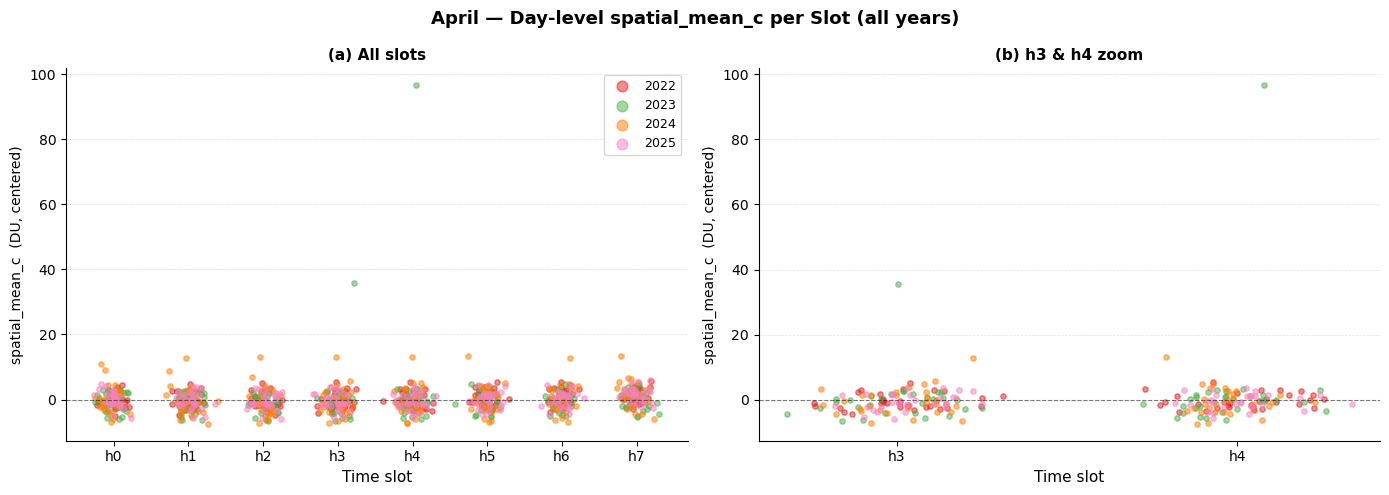

Saved → apr_day_strip.png


In [6]:
# ── April day-by-day spatial mean (centered) per slot ─────────────────────────
# 각 연도별로 색 구분

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('April — Day-level spatial_mean_c per Slot (all years)',
             fontsize=13, fontweight='bold')

for ax_idx, focus_slots in enumerate([[0,1,2,3,4,5,6,7], [3,4]]):
    ax = axes[ax_idx]
    title = '(a) All slots' if ax_idx == 0 else '(b) h3 & h4 zoom'
    for i, yr in enumerate(YEARS):
        sub = df[df['year'] == int(yr)]
        for slot in focus_slots:
            vals = sub[sub['slot'] == slot]['spatial_mean_c'].values
            jitter = np.random.normal(0, 0.12, size=len(vals))
            ax.scatter(
                np.full(len(vals), slot) + jitter,
                vals,
                color=YEAR_PALETTE[yr], alpha=0.5, s=15,
                label=yr if slot == focus_slots[0] else None
            )
    # 수평선 y=0
    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_xticks(focus_slots); ax.set_xticklabels([f'h{s}' for s in focus_slots], fontsize=10)
    ax.set_xlabel('Time slot', fontsize=11)
    ax.set_ylabel('spatial_mean_c  (DU, centered)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.4)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    if ax_idx == 0:
        ax.legend(fontsize=9, markerscale=2, framealpha=0.8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'apr_day_strip.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → apr_day_strip.png")

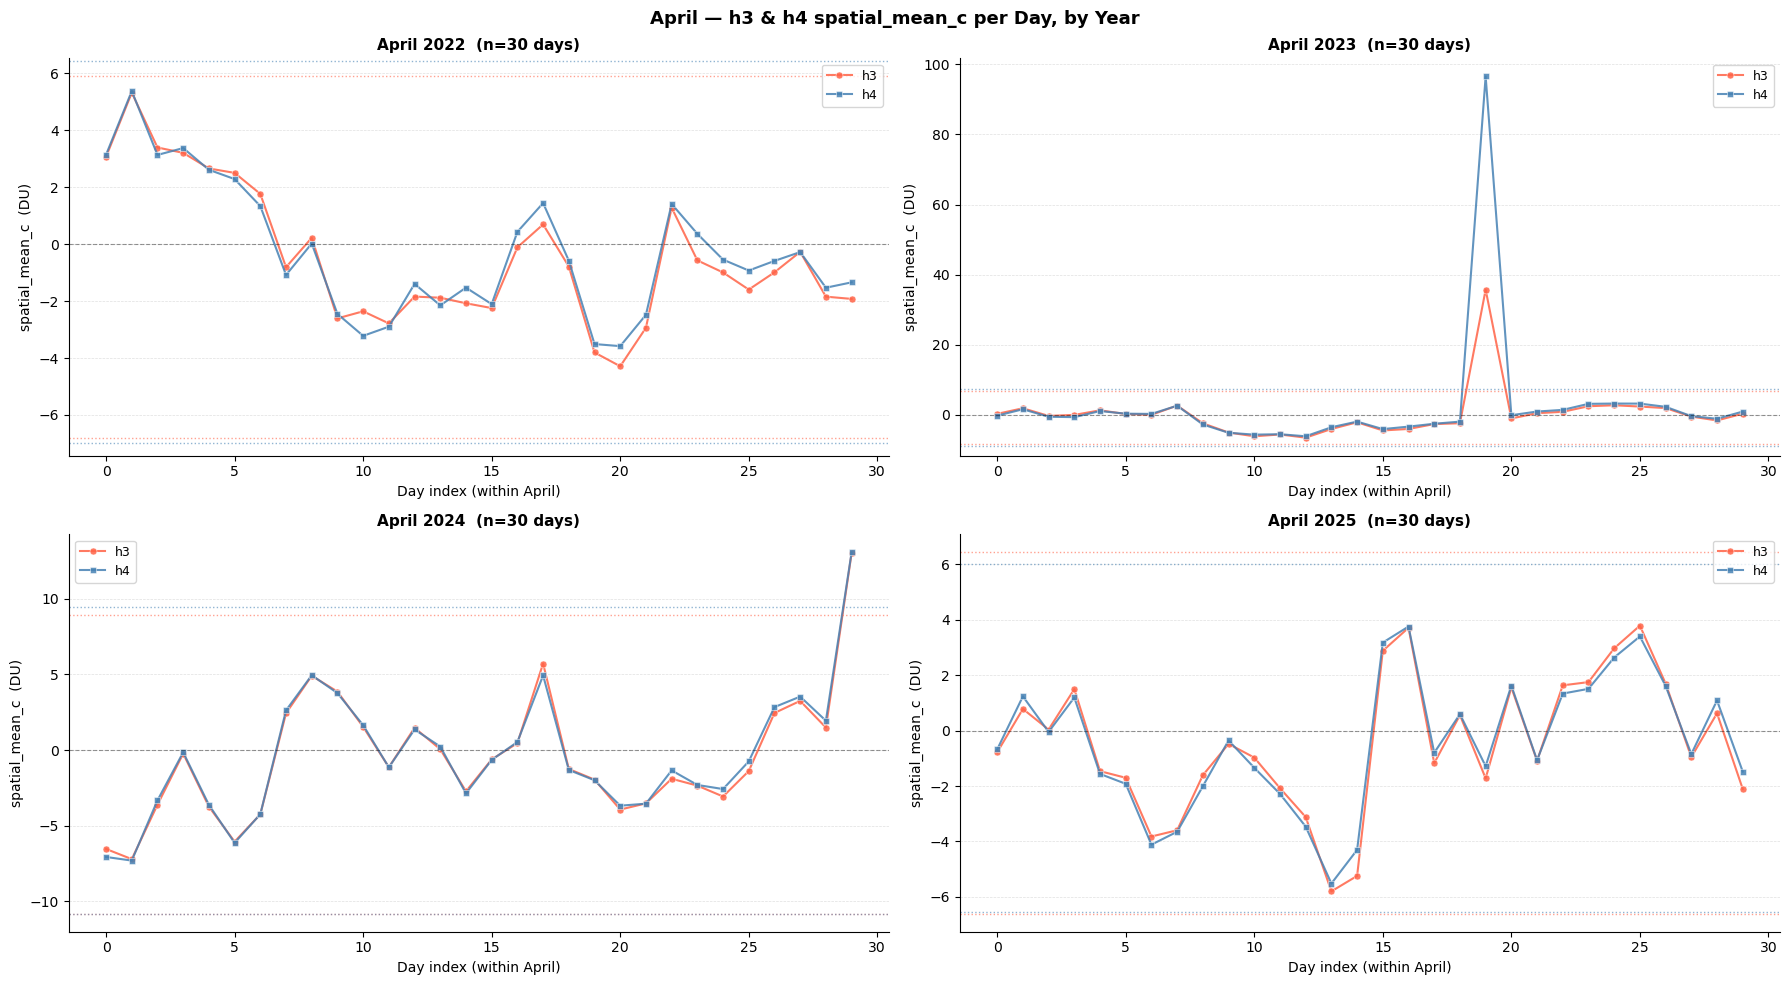

Saved → apr_h34_timeseries_yearly.png


In [7]:
# ── Year-by-year time series of h3, h4 spatial_mean_c (April) ─────────────────
# x축: day_idx within April

fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=False)
fig.suptitle('April — h3 & h4 spatial_mean_c per Day, by Year',
             fontsize=13, fontweight='bold')

for ax, yr in zip(axes.ravel(), YEARS):
    sub = df[df['year'] == int(yr)]
    n_days_yr = sub['day_idx'].nunique()

    for slot, color, marker in [(3, 'tomato', 'o'), (4, 'steelblue', 's')]:
        sub_slot = sub[sub['slot'] == slot].sort_values('day_idx')
        ax.plot(sub_slot['day_idx'].values,
                sub_slot['spatial_mean_c'].values,
                f'{marker}-', color=color, lw=1.5, ms=5,
                markeredgecolor='white', markeredgewidth=0.4,
                label=f'h{slot}', alpha=0.85)

    # IQR-based outlier threshold lines
    for slot, color in [(3, 'tomato'), (4, 'steelblue')]:
        vals = sub[sub['slot'] == slot]['spatial_mean_c'].dropna().values
        if len(vals) > 3:
            q1, q3 = np.percentile(vals, 25), np.percentile(vals, 75)
            iqr = q3 - q1
            ax.axhline(q3 + 1.5*iqr, color=color, ls=':', lw=1.0, alpha=0.6)
            ax.axhline(q1 - 1.5*iqr, color=color, ls=':', lw=1.0, alpha=0.6)

    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.4)
    ax.set_title(f'April {yr}  (n={n_days_yr} days)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Day index (within April)', fontsize=10)
    ax.set_ylabel('spatial_mean_c  (DU)', fontsize=10)
    ax.legend(fontsize=9, framealpha=0.8)
    ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.4)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_DIR / 'apr_h34_timeseries_yearly.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → apr_h34_timeseries_yearly.png")

---
## Section 3 — Day × Hour Heatmap (April)

각 날의 8개 slot spatial_mean_c를 2D heatmap으로 → 패턴이 month 전체에 걸쳐 consistent한지 확인
- x축: time slot (h0–h7)
- y축: day (1–30)
- 색: spatial_mean_c 값

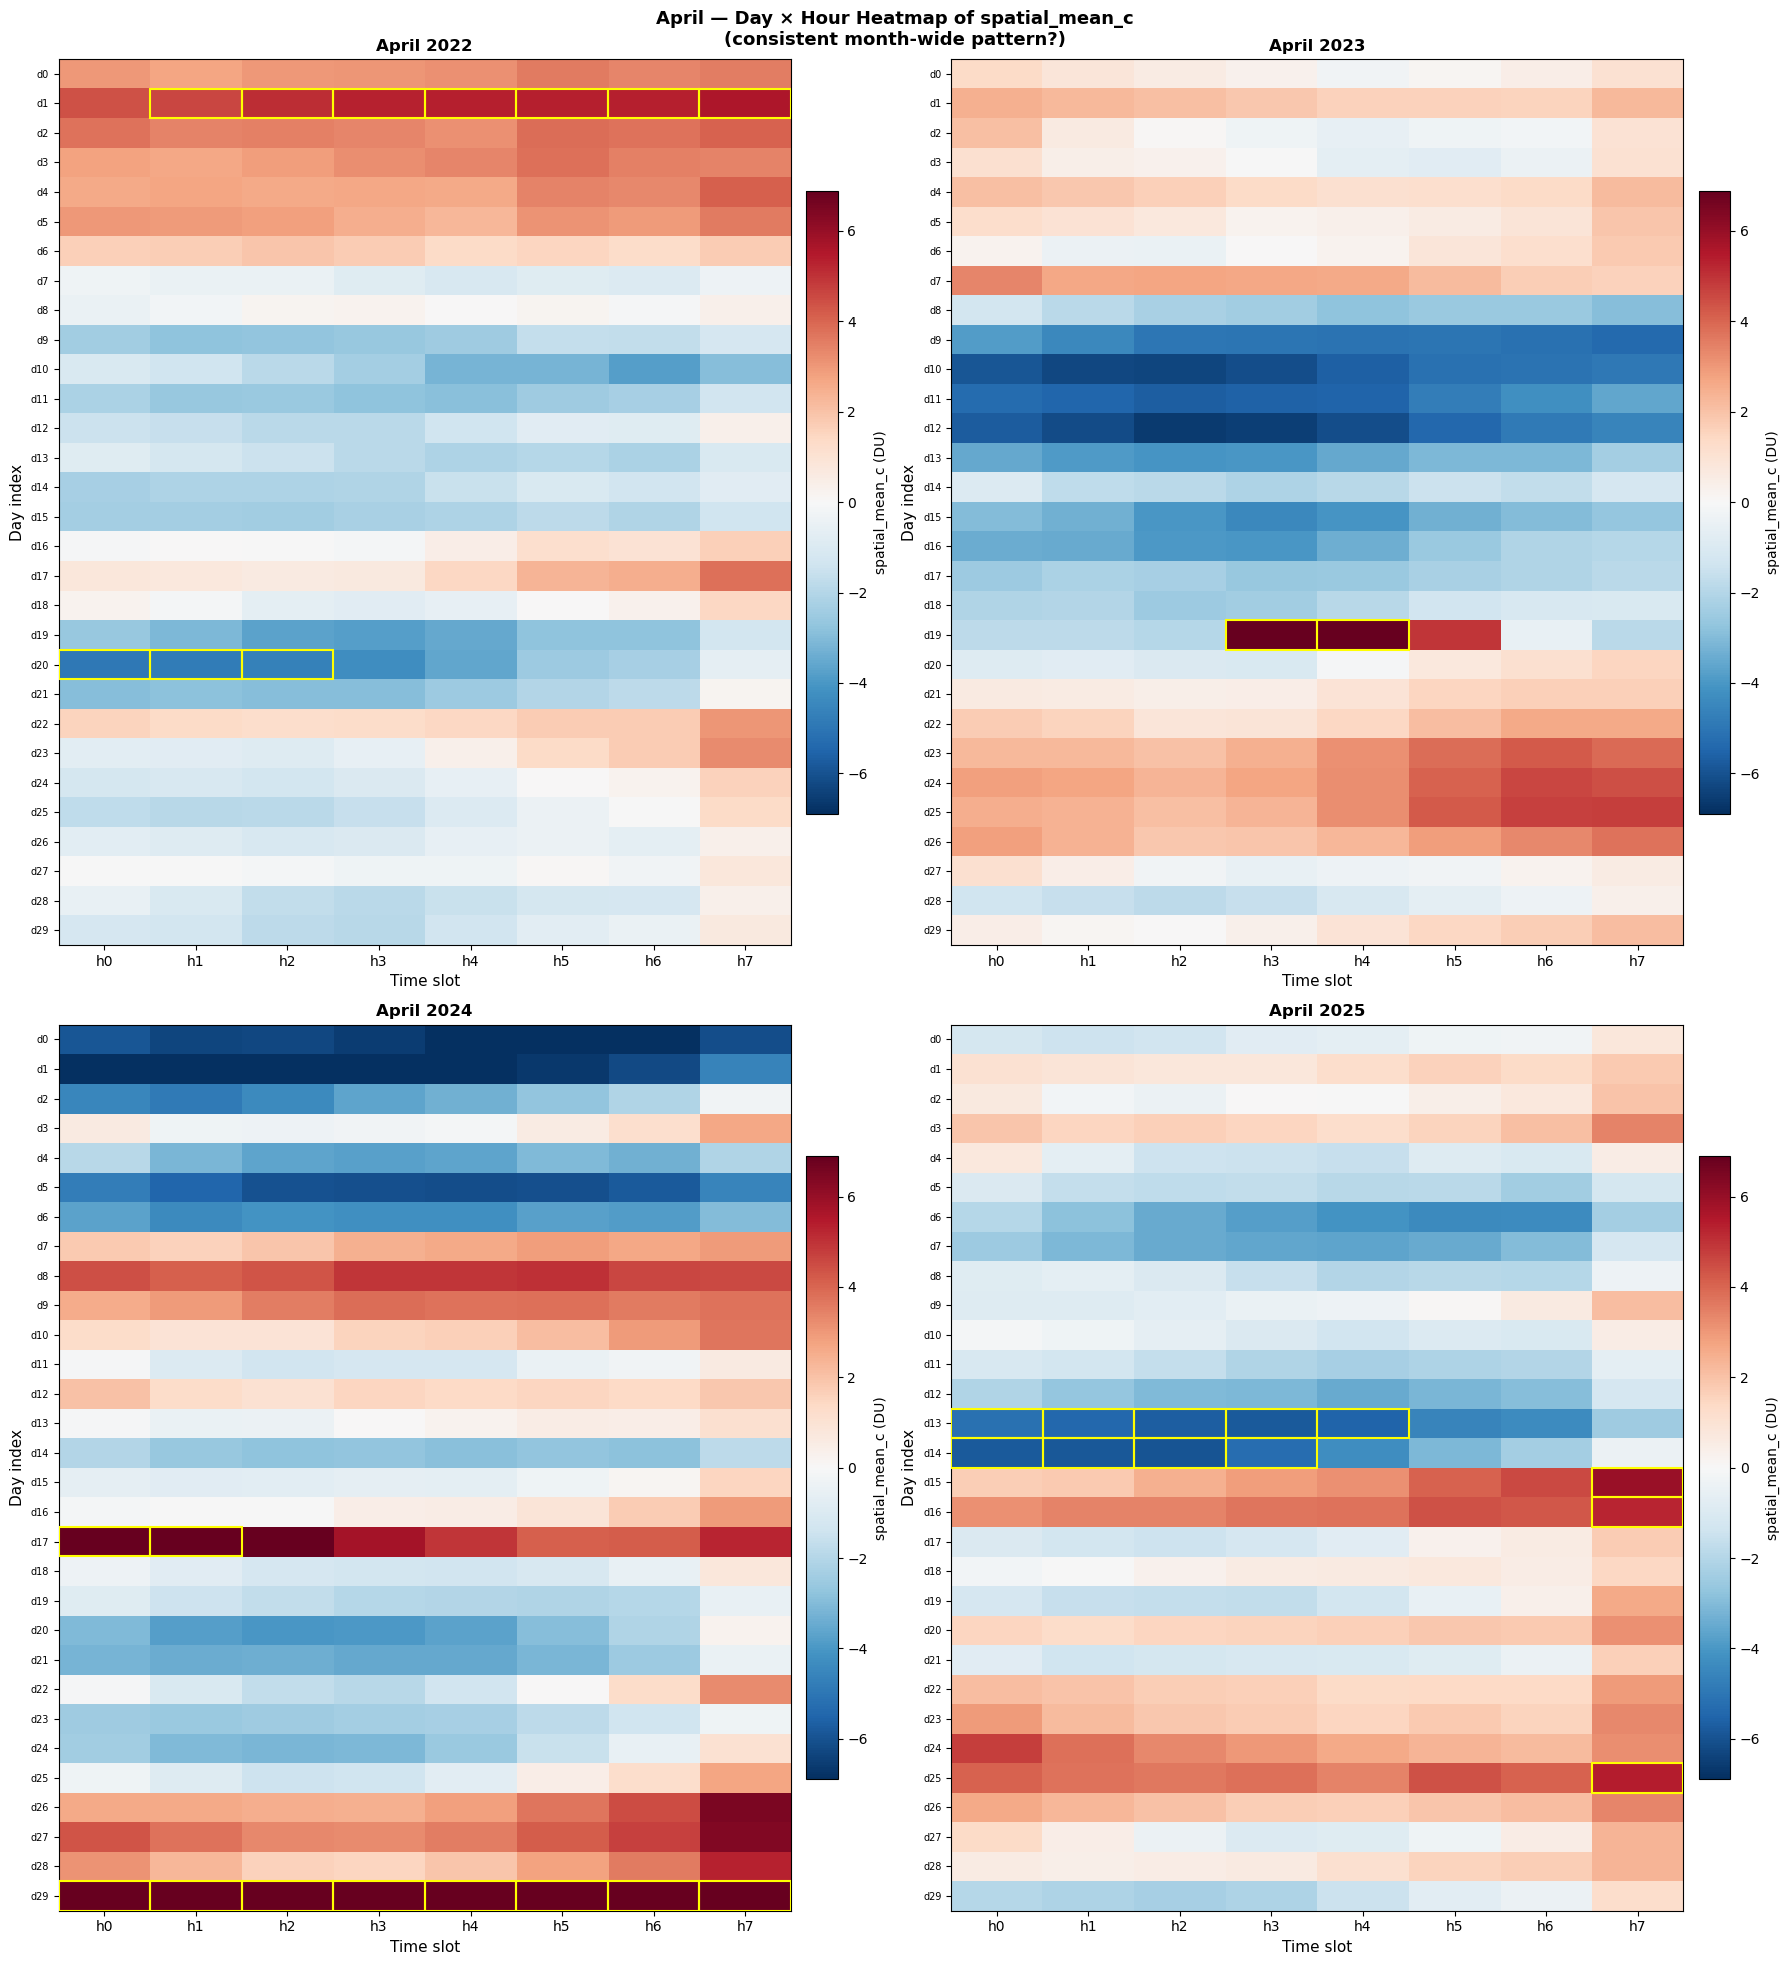

Saved → apr_day_hour_heatmap.png

Yellow borders = |spatial_mean_c| > 2σ (potential outlier cells)


In [8]:
# ── April Day × Hour heatmap, year-by-year ────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(18, 20))
fig.suptitle('April — Day × Hour Heatmap of spatial_mean_c\n(consistent month-wide pattern?)',
             fontsize=13, fontweight='bold')

# global colorscale
vmax_global = df['spatial_mean_c'].abs().quantile(0.98)

for ax, yr in zip(axes.ravel(), YEARS):
    sub = df[df['year'] == int(yr)]
    day_indices = sorted(sub['day_idx'].unique())
    n_days_yr = len(day_indices)

    # Build matrix: rows=days, cols=slots
    mat = np.full((n_days_yr, N_SLOTS), np.nan)
    for row_i, d_idx in enumerate(day_indices):
        s = sub[sub['day_idx'] == d_idx]
        for _, r in s.iterrows():
            mat[row_i, int(r['slot'])] = r['spatial_mean_c']

    im = ax.imshow(mat, cmap='RdBu_r', vmin=-vmax_global, vmax=vmax_global,
                   aspect='auto', interpolation='nearest')
    ax.set_xticks(range(N_SLOTS)); ax.set_xticklabels(SLOT_LABELS, fontsize=10)
    ax.set_yticks(range(n_days_yr))
    ax.set_yticklabels([f'd{d}' for d in day_indices], fontsize=7)
    ax.set_xlabel('Time slot', fontsize=11)
    ax.set_ylabel('Day index', fontsize=11)
    ax.set_title(f'April {yr}', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label='spatial_mean_c (DU)')

    # Mark cells with |val| > 2σ
    sigma = np.nanstd(mat)
    for ri in range(n_days_yr):
        for ci in range(N_SLOTS):
            v = mat[ri, ci]
            if np.isfinite(v) and abs(v) > 2 * sigma:
                ax.add_patch(plt.Rectangle((ci-0.5, ri-0.5), 1, 1,
                                           fill=False, edgecolor='yellow',
                                           lw=1.5, zorder=5))

plt.tight_layout()
plt.savefig(OUT_DIR / 'apr_day_hour_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → apr_day_hour_heatmap.png")
print("\nYellow borders = |spatial_mean_c| > 2σ (potential outlier cells)")

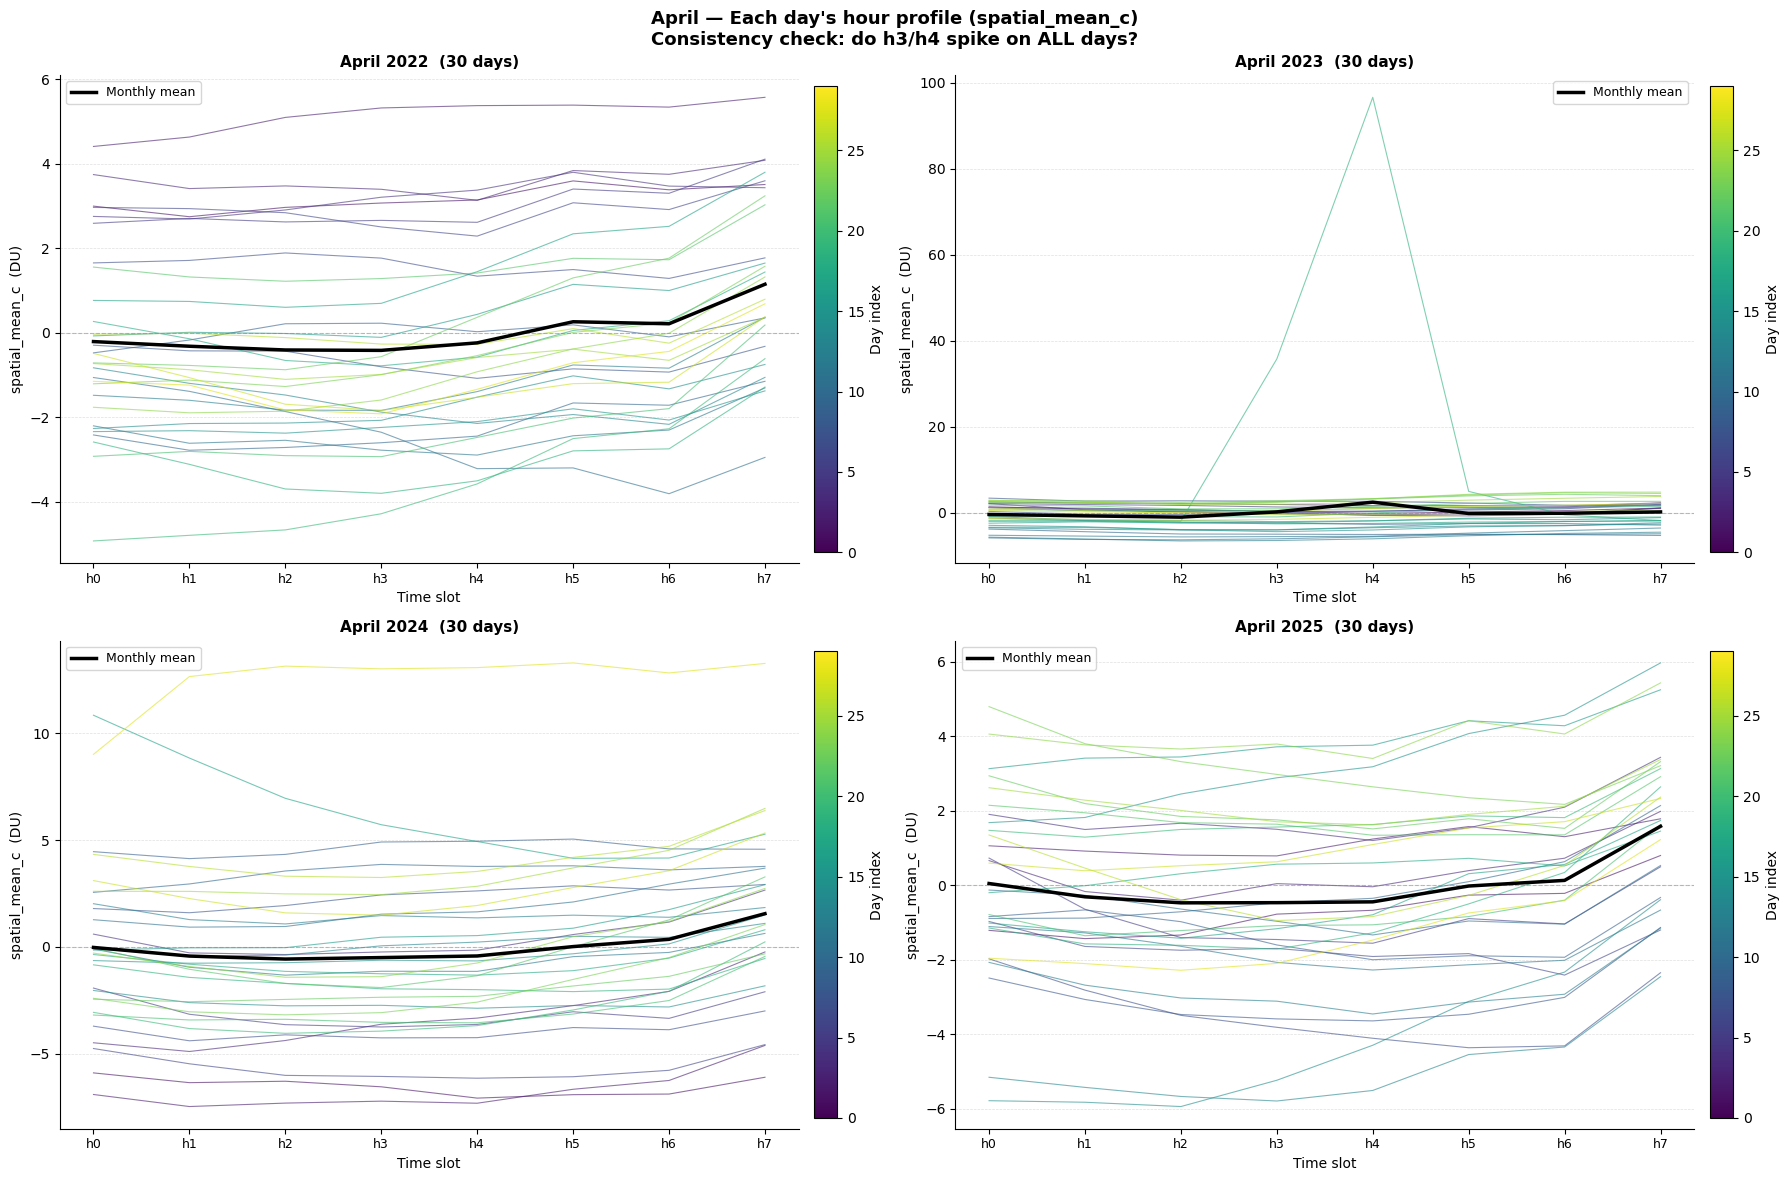

Saved → apr_hourly_profile_per_day.png


In [9]:
# ── Hour profile per day: each day plotted as a line, by year ─────────────────
# → h3/h4 spike가 특정 소수 일에만 나타나면 outlier 의심

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('April — Each day\'s hour profile (spatial_mean_c)\nConsistency check: do h3/h4 spike on ALL days?',
             fontsize=13, fontweight='bold')

for ax, yr in zip(axes.ravel(), YEARS):
    sub = df[df['year'] == int(yr)]
    day_indices = sorted(sub['day_idx'].unique())
    n_days_yr = len(day_indices)
    cmap_days = cm.viridis(np.linspace(0.05, 0.95, n_days_yr))

    for row_i, d_idx in enumerate(day_indices):
        s = sub[sub['day_idx'] == d_idx].sort_values('slot')
        slots_vals = s[['slot', 'spatial_mean_c']].dropna()
        ax.plot(slots_vals['slot'].values,
                slots_vals['spatial_mean_c'].values,
                '-', color=cmap_days[row_i], lw=0.8, alpha=0.6)

    # Mean profile over all days (bold)
    mean_profile = sub.groupby('slot')['spatial_mean_c'].mean().reindex(range(N_SLOTS)).values
    ax.plot(range(N_SLOTS), mean_profile, 'k-', lw=2.5, label='Monthly mean', zorder=10)
    ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.5)

    ax.set_title(f'April {yr}  ({n_days_yr} days)', fontsize=11, fontweight='bold')
    ax.set_xticks(range(N_SLOTS)); ax.set_xticklabels(SLOT_LABELS, fontsize=9)
    ax.set_xlabel('Time slot', fontsize=10)
    ax.set_ylabel('spatial_mean_c  (DU)', fontsize=10)
    ax.legend(fontsize=9, framealpha=0.8)
    ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.4)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # Add colorbar for day index
    sm = plt.cm.ScalarMappable(cmap='viridis',
                               norm=plt.Normalize(vmin=day_indices[0], vmax=day_indices[-1]))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02, label='Day index')

plt.tight_layout()
plt.savefig(OUT_DIR / 'apr_hourly_profile_per_day.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → apr_hourly_profile_per_day.png")

---
## Section 4 — Outlier Day 식별 및 제거 후 C[h,h] 재계산

h3, h4에서 |spatial_mean_c| > threshold인 날을 outlier로 정의하고:
1. 어떤 날(day_idx, year)이 outlier인지 목록 출력
2. outlier 제거 후 C[h,h] 재계산 → spike가 얼마나 감소하는지

In [10]:
# ── IQR-based outlier detection for h3, h4 ────────────────────────────────────
outlier_days = set()

print("=" * 65)
print("Outlier days in April (|val| > Q3 + 1.5*IQR for h3 or h4)")
print("=" * 65)

for slot in [3, 4]:
    sub_slot = df[df['slot'] == slot]['spatial_mean_c'].dropna()
    q1, q3 = sub_slot.quantile(0.25), sub_slot.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr
    print(f"\nh{slot}:  Q1={q1:.2f}  Q3={q3:.2f}  IQR={iqr:.2f}")
    print(f"  Outlier bounds: [{lower:.2f}, {upper:.2f}]")

    mask = (df['slot'] == slot) & (
        (df['spatial_mean_c'] > upper) | (df['spatial_mean_c'] < lower)
    )
    outliers = df[mask][['year', 'day_idx', 'spatial_mean_c']].sort_values('spatial_mean_c', ascending=False)
    print(f"  Outlier observations (n={len(outliers)}):")
    for _, r in outliers.iterrows():
        key = (int(r['year']), int(r['day_idx']))
        outlier_days.add(key)
        print(f"    year={r['year']}  day_idx={r['day_idx']}  val={r['spatial_mean_c']:.3f}")

print(f"\nTotal unique outlier days: {len(outlier_days)}")
print("Outlier (year, day_idx):")
for k in sorted(outlier_days):
    print(f"  {k}")

Outlier days in April (|val| > Q3 + 1.5*IQR for h3 or h4)

h3:  Q1=-2.37  Q3=1.51  IQR=3.87
  Outlier bounds: [-8.18, 7.32]
  Outlier observations (n=2):
    year=2023.0  day_idx=19.0  val=35.716
    year=2024.0  day_idx=29.0  val=13.005

h4:  Q1=-2.34  Q3=1.43  IQR=3.77
  Outlier bounds: [-8.00, 7.08]
  Outlier observations (n=2):
    year=2023.0  day_idx=19.0  val=96.560
    year=2024.0  day_idx=29.0  val=13.062

Total unique outlier days: 2
Outlier (year, day_idx):
  (2023, 19)
  (2024, 29)


In [11]:
# ── outlier day 제거 후 C[h,h] 재계산 ────────────────────────────────────────

def is_outlier_day(yr, d_idx):
    return (int(yr), int(d_idx)) in outlier_days

df_clean = df[~df.apply(lambda r: is_outlier_day(r['year'], r['day_idx']), axis=1)].copy()
print(f"Rows after outlier removal: {len(df)} → {len(df_clean)}  (removed {len(df)-len(df_clean)})")

# All years pooled
Y_clean, _ = build_Y_for_subset(df_clean)
C_clean = sample_cov_matrix(Y_clean)
diag_orig  = np.diag(C_all_apr)
diag_clean = np.diag(C_clean)

print("\nC[h,h] comparison (all April years pooled):")
print(f"{'slot':>6}  {'original':>10}  {'no_outlier':>12}  {'diff':>8}")
for h in range(N_SLOTS):
    diff = diag_clean[h] - diag_orig[h]
    print(f"  h{h}    {diag_orig[h]:>10.2f}  {diag_clean[h]:>12.2f}  {diff:>+8.2f}")

Rows after outlier removal: 960 → 944  (removed 16)

C[h,h] comparison (all April years pooled):
  slot    original    no_outlier      diff
  h0          8.22          7.64     -0.58
  h1          8.99          7.76     -1.23
  h2          9.33          7.99     -1.34
  h3         19.91          8.00    -11.91
  h4         86.66          7.67    -78.99
  h5          8.81          7.26     -1.55
  h6          8.43          7.18     -1.25
  h7          9.34          7.98     -1.36


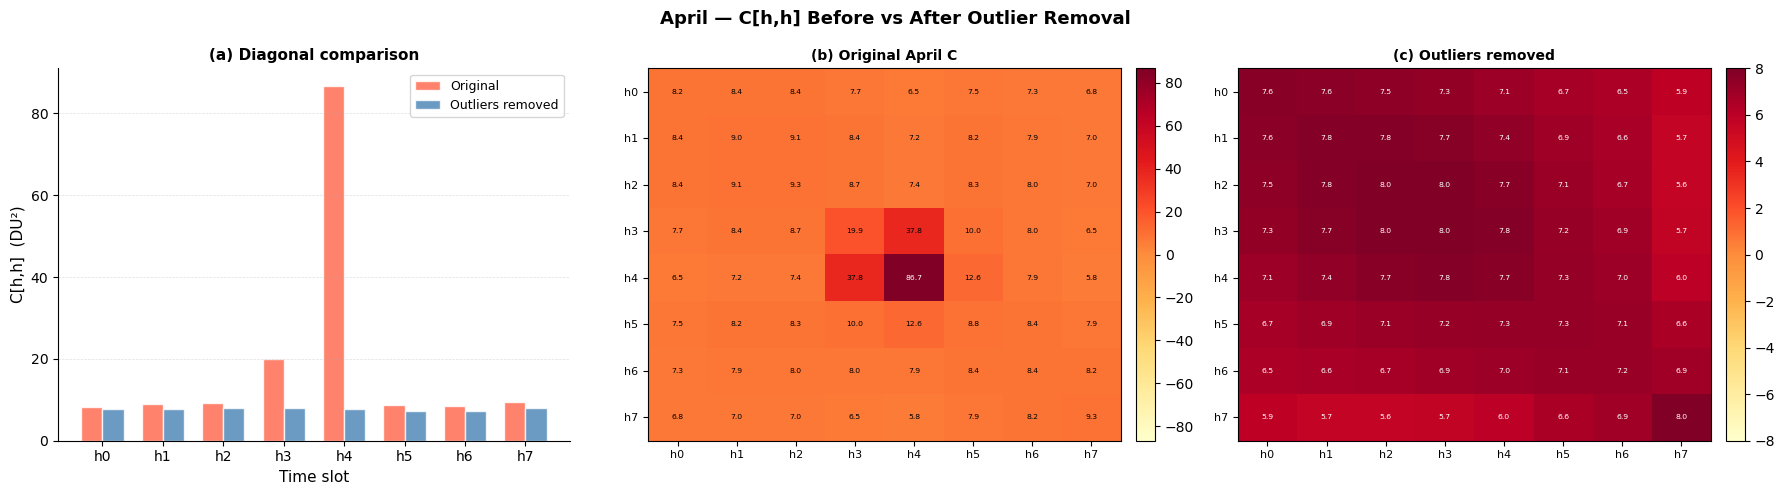

Saved → apr_outlier_compare.png


In [12]:
# ── Before vs After outlier removal: C[h,h] comparison ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('April — C[h,h] Before vs After Outlier Removal',
             fontsize=13, fontweight='bold')

x = np.arange(N_SLOTS)
w = 0.35

# (a) Bar comparison
ax = axes[0]
ax.bar(x - w/2, diag_orig,  w, label='Original',      color='tomato',    alpha=0.8, edgecolor='white')
ax.bar(x + w/2, diag_clean, w, label='Outliers removed', color='steelblue', alpha=0.8, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(SLOT_LABELS, fontsize=10)
ax.set_xlabel('Time slot', fontsize=11)
ax.set_ylabel('C[h,h]  (DU²)', fontsize=11)
ax.set_title('(a) Diagonal comparison', fontsize=11, fontweight='bold')
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.4)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# (b) 8×8 original
plot_cov_heatmap(axes[1], C_all_apr, title='(b) Original April C', cmap='YlOrRd', annotate=True)

# (c) 8×8 clean
plot_cov_heatmap(axes[2], C_clean, title='(c) Outliers removed', cmap='YlOrRd', annotate=True)

plt.tight_layout()
plt.savefig(OUT_DIR / 'apr_outlier_compare.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → apr_outlier_compare.png")

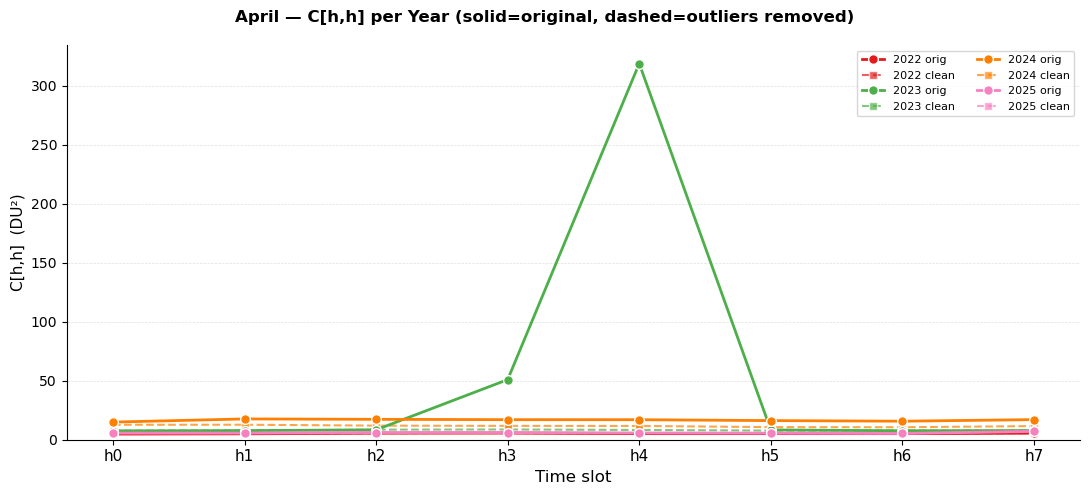

Saved → apr_yearly_clean_diag.png


In [13]:
# ── Year-by-year C[h,h] after outlier removal ─────────────────────────────────
yearly_C_clean = {}
for yr in YEARS:
    sub_clean = df_clean[df_clean['year'] == int(yr)]
    if len(sub_clean) == 0:
        continue
    Y_c, _ = build_Y_for_subset(sub_clean)
    yearly_C_clean[yr] = sample_cov_matrix(Y_c)

fig, ax = plt.subplots(figsize=(11, 5))
fig.suptitle('April — C[h,h] per Year (solid=original, dashed=outliers removed)',
             fontsize=12, fontweight='bold')

for i, yr in enumerate(YEARS):
    color = YEAR_PALETTE[yr]
    if yr in yearly_C:
        ax.plot(range(N_SLOTS), np.diag(yearly_C[yr]),
                'o-', color=color, lw=2.0, ms=7,
                markeredgecolor='white', label=f'{yr} orig', zorder=5+i)
    if yr in yearly_C_clean:
        ax.plot(range(N_SLOTS), np.diag(yearly_C_clean[yr]),
                's--', color=color, lw=1.5, ms=6, alpha=0.7,
                markeredgecolor='white', label=f'{yr} clean', zorder=3+i)

ax.set_xticks(range(N_SLOTS)); ax.set_xticklabels(SLOT_LABELS, fontsize=11)
ax.set_xlabel('Time slot', fontsize=12)
ax.set_ylabel('C[h,h]  (DU²)', fontsize=11)
ax.set_ylim(bottom=0)
ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.4)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(fontsize=8, ncol=2, framealpha=0.8, loc='upper right')

plt.tight_layout()
plt.savefig(OUT_DIR / 'apr_yearly_clean_diag.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → apr_yearly_clean_diag.png")

---
## Section 5 — Actual spatial_mean (uncentered) per Day × Hour

centered 값이 아닌 raw spatial_mean을 보여서 절대적인 TCO 수준 변화도 확인
- h3/h4 spike가 TCO 절대값이 특정 날 극단적으로 높거나 낮아서 생기는지

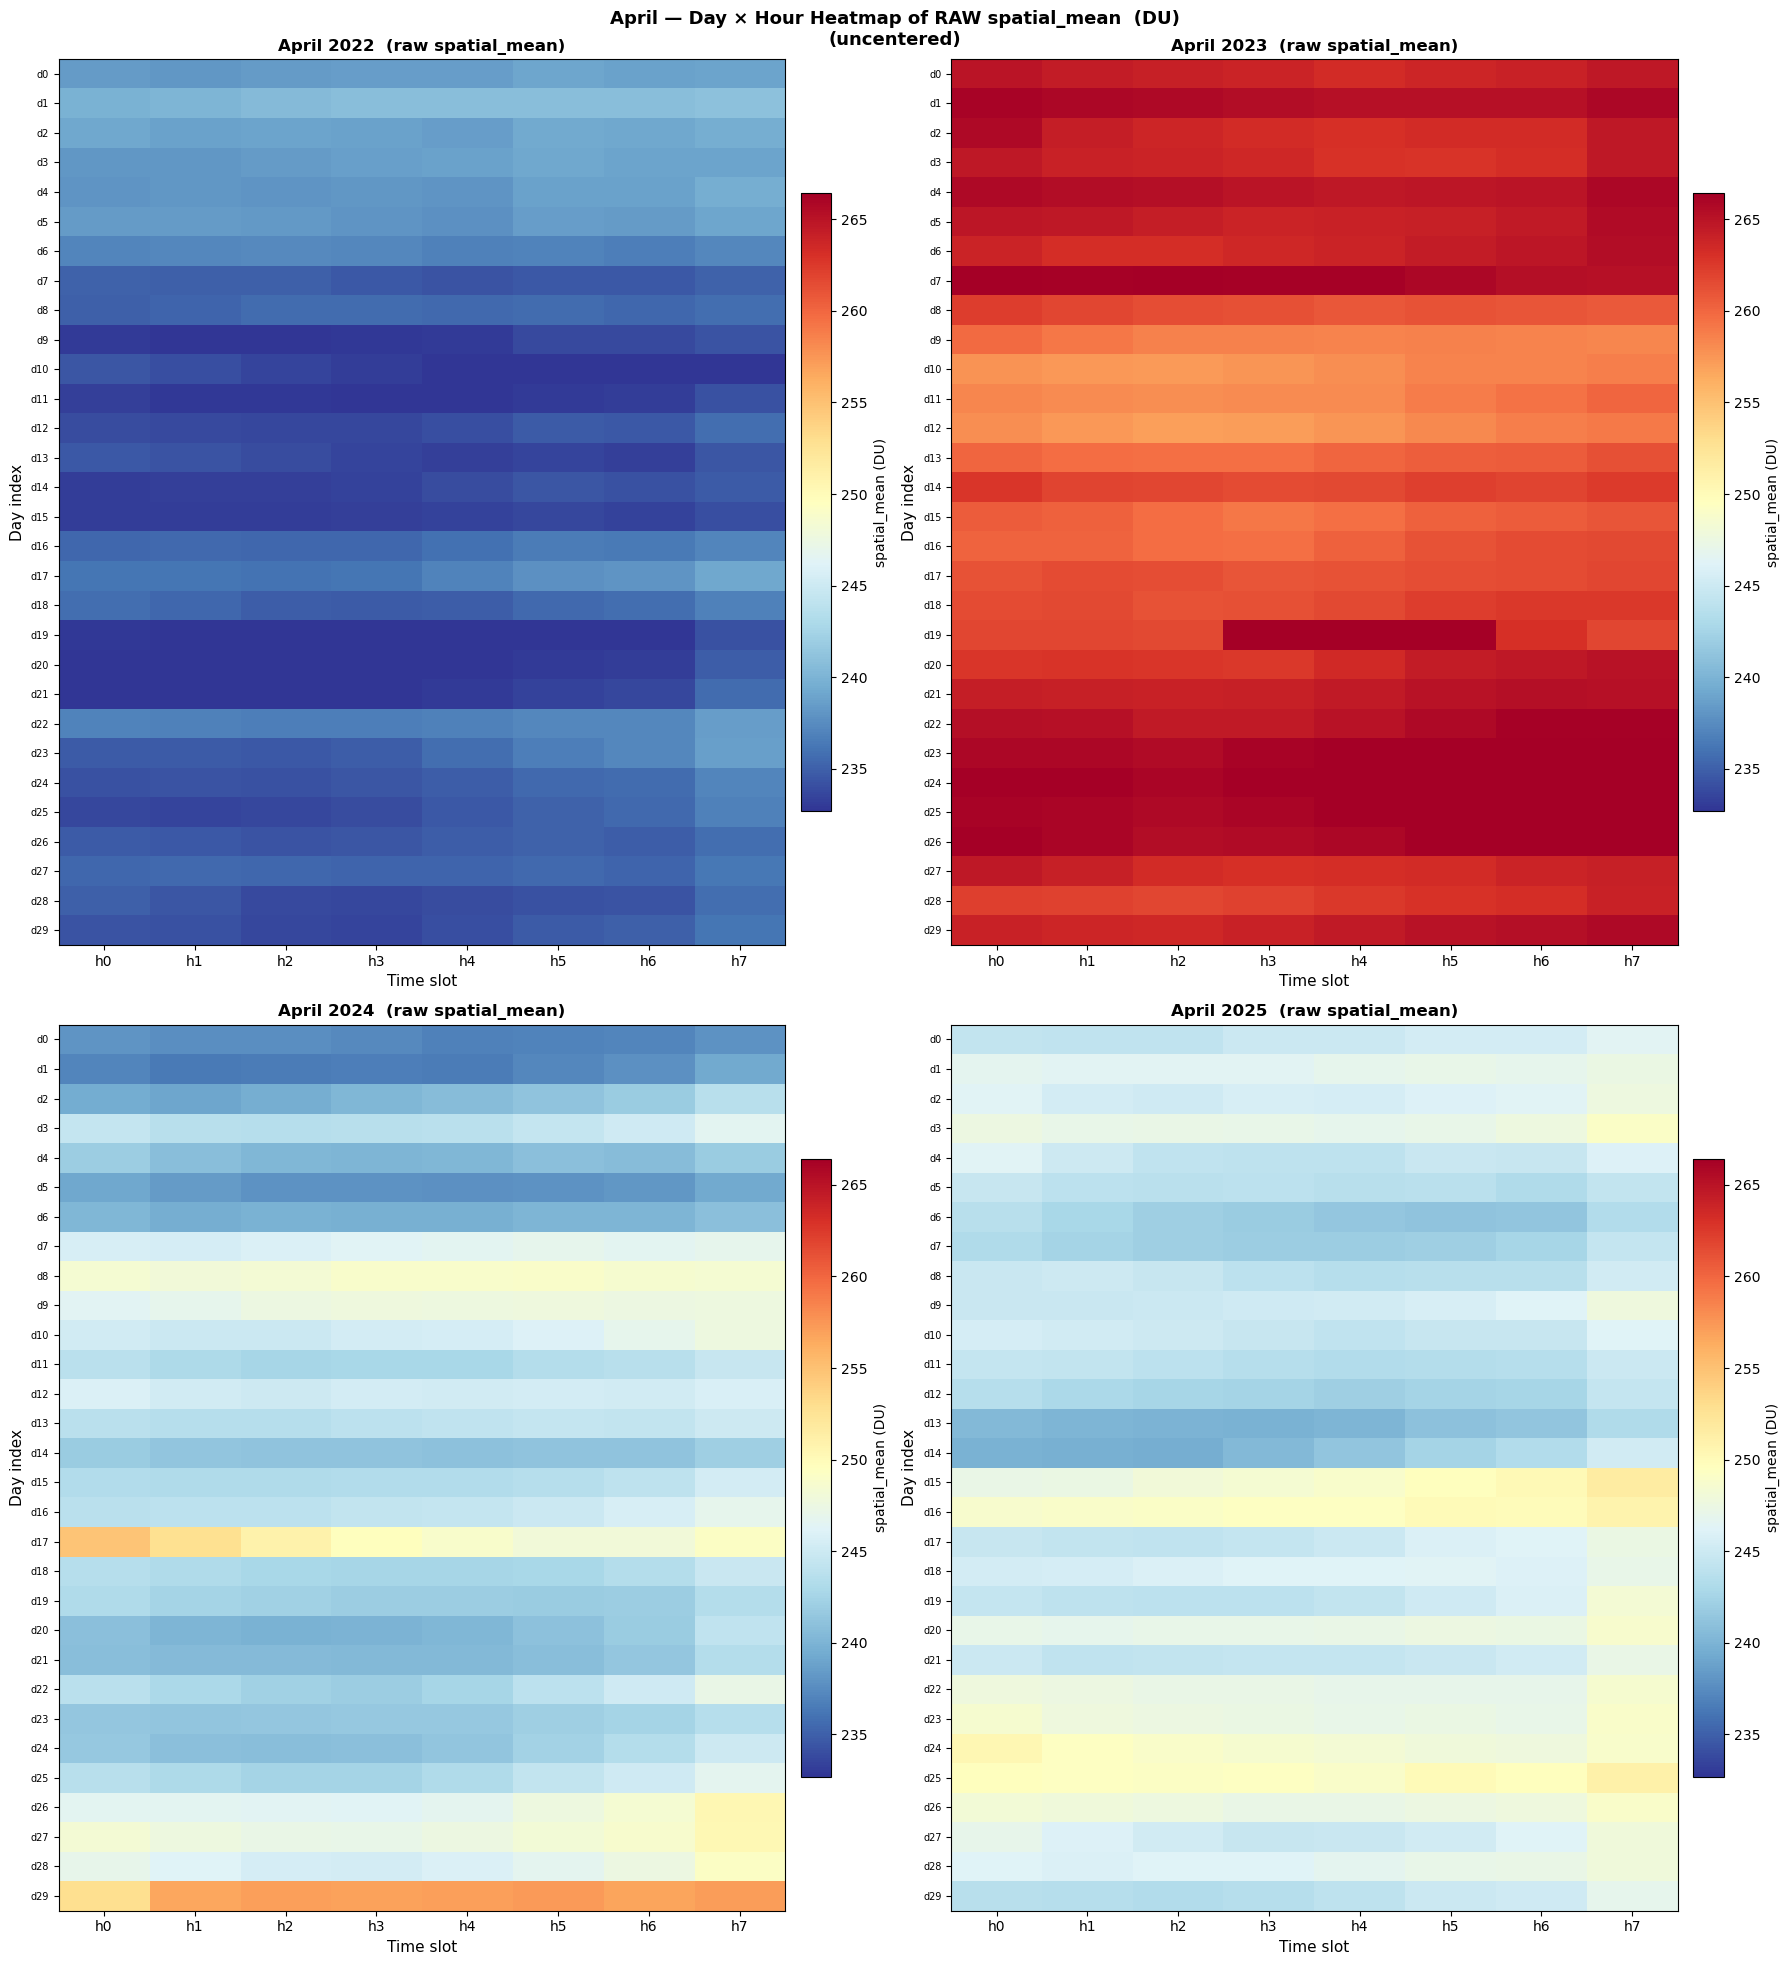

Saved → apr_raw_mean_heatmap.png


In [14]:
# ── Raw spatial_mean Day × Hour heatmap (April, year-by-year) ─────────────────

fig, axes = plt.subplots(2, 2, figsize=(18, 20))
fig.suptitle('April — Day × Hour Heatmap of RAW spatial_mean  (DU)\n(uncentered)',
             fontsize=13, fontweight='bold')

vmax_raw = df['spatial_mean'].quantile(0.98)
vmin_raw = df['spatial_mean'].quantile(0.02)

for ax, yr in zip(axes.ravel(), YEARS):
    sub = df[df['year'] == int(yr)]
    day_indices = sorted(sub['day_idx'].unique())
    n_days_yr = len(day_indices)

    mat = np.full((n_days_yr, N_SLOTS), np.nan)
    for row_i, d_idx in enumerate(day_indices):
        s = sub[sub['day_idx'] == d_idx]
        for _, r in s.iterrows():
            mat[row_i, int(r['slot'])] = r['spatial_mean']

    im = ax.imshow(mat, cmap='RdYlBu_r', vmin=vmin_raw, vmax=vmax_raw,
                   aspect='auto', interpolation='nearest')
    ax.set_xticks(range(N_SLOTS)); ax.set_xticklabels(SLOT_LABELS, fontsize=10)
    ax.set_yticks(range(n_days_yr))
    ax.set_yticklabels([f'd{d}' for d in day_indices], fontsize=7)
    ax.set_xlabel('Time slot', fontsize=11)
    ax.set_ylabel('Day index', fontsize=11)
    ax.set_title(f'April {yr}  (raw spatial_mean)', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label='spatial_mean (DU)')

plt.tight_layout()
plt.savefig(OUT_DIR / 'apr_raw_mean_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → apr_raw_mean_heatmap.png")

---
## Summary

| 분석 | 확인 사항 | 결론 |
|------|-----------|------|
| Sec 1 | 연도별 8×8 C 행렬 | h3/h4 spike가 매년 나타나는지? |
| Sec 2 | Day-by-day strip & 시계열 | outlier day 존재? |
| Sec 3 | Day × Hour heatmap | 패턴이 month 전체에 consistent? |
| Sec 4 | Outlier 제거 후 재계산 | spike가 outlier days 때문인지? |
| Sec 5 | Raw mean heatmap | TCO 절대값 관점에서 이상일? |

**결론 작성 공간** (셀 실행 후 채울 것)